In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler



In [136]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [137]:
df = pd.read_csv("C:/Users/Administrator/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [138]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [139]:
df.shape

(7043, 21)

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [141]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [142]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [143]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [144]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [145]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [146]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [147]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [148]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [149]:
df.dropna(inplace=True)

In [150]:
#Exploratory Data Analysis (EDA)

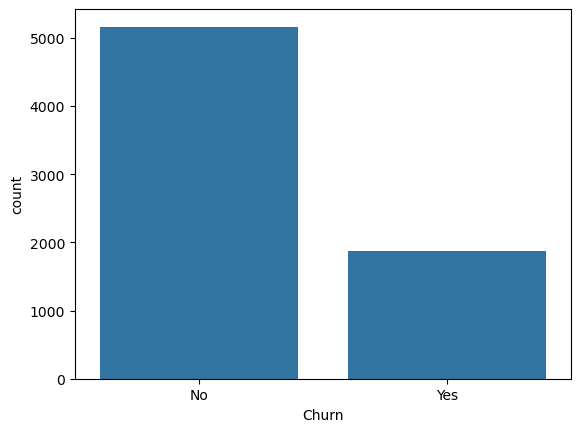

In [151]:
sns.countplot(x="Churn", data=df)
plt.show()

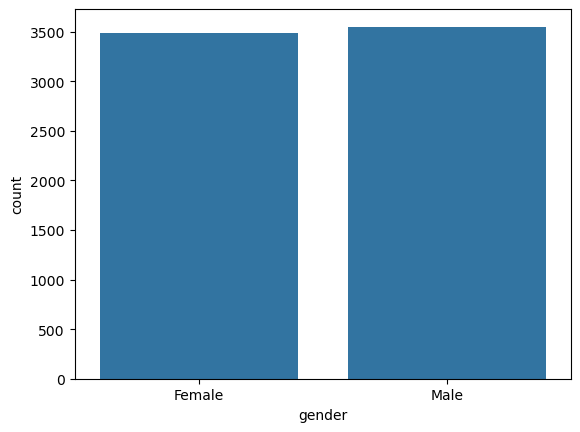

In [152]:
sns.countplot(x="gender", data=df)
plt.show()

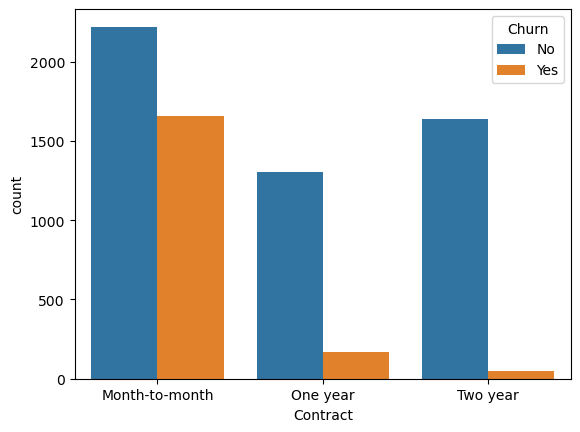

In [153]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

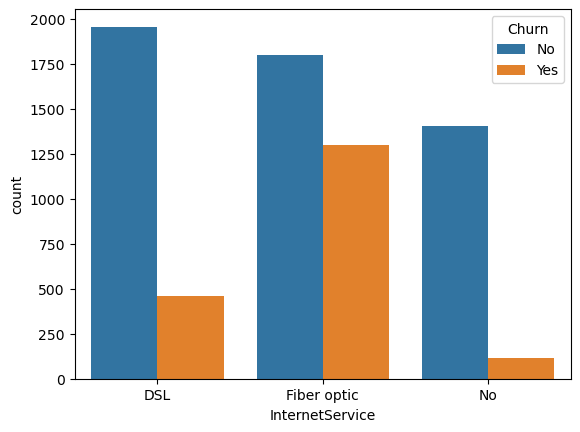

In [154]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

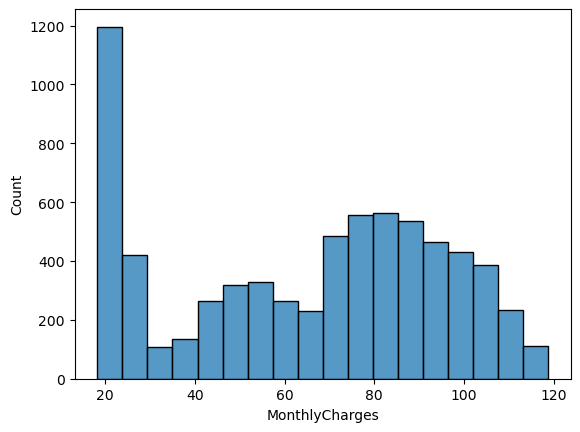

In [155]:
sns.histplot(df["MonthlyCharges"])
plt.show()

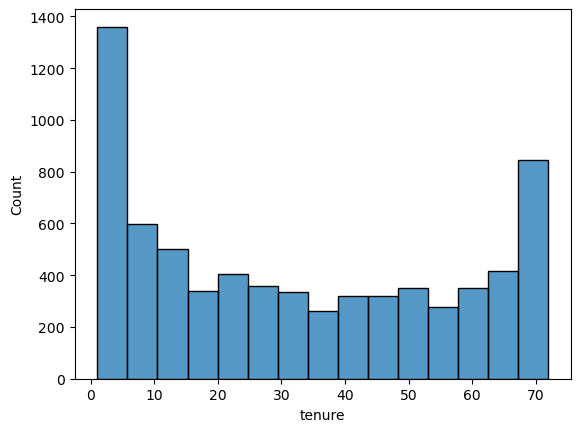

In [156]:
sns.histplot(df["tenure"])
plt.show()

In [157]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

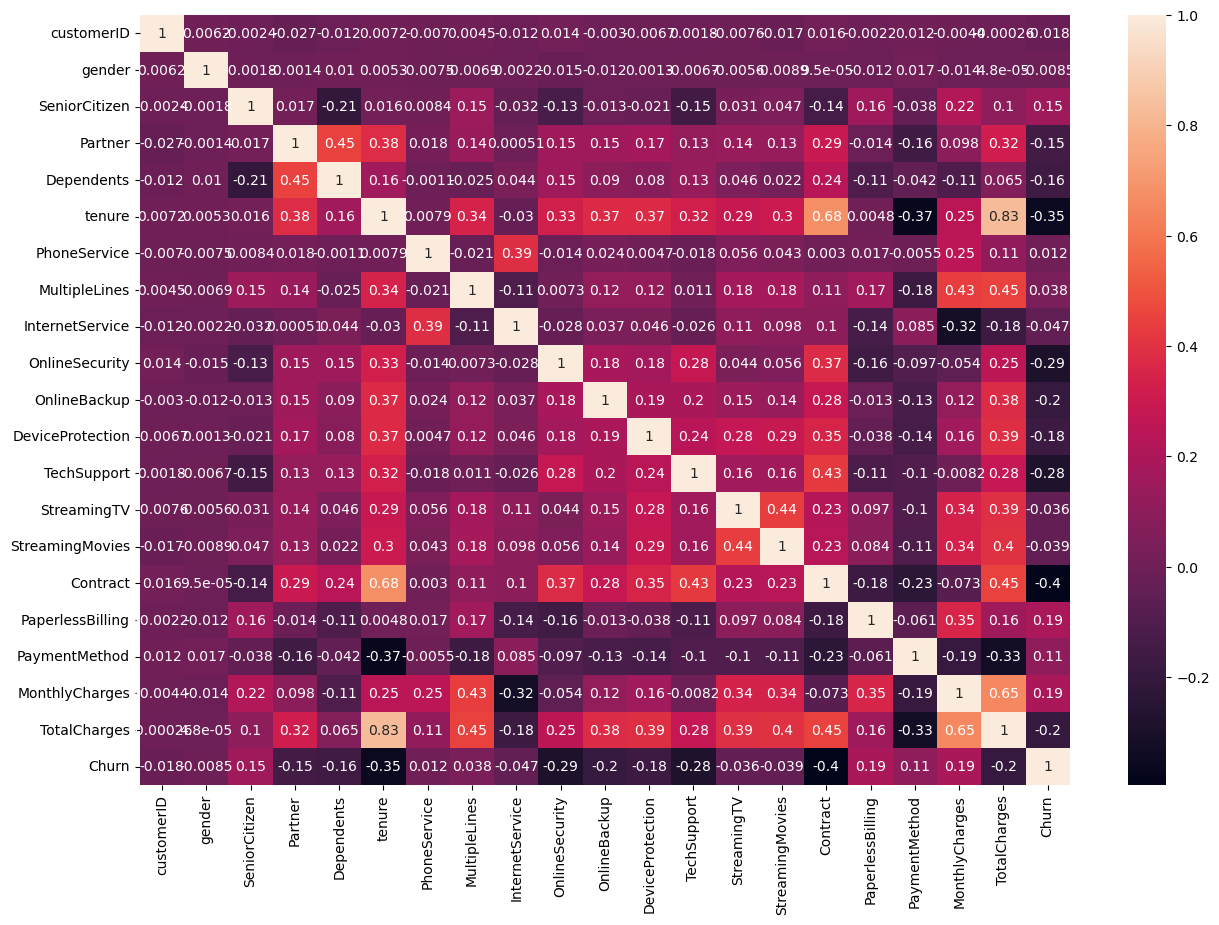

In [158]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [159]:
##Data Preprocessing

In [160]:
df.drop("customerID",axis=1,inplace=True)

In [161]:
le=LabelEncoder()

for col in df.columns:
    if df[col].dtype=="object":
        df[col]=le.fit_transform(df[col])

In [162]:
x = df.drop("Churn",axis=1)
y = df["Churn"]

In [163]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [164]:
#Feature Scaling

In [165]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [166]:
#Train Models
#Logistic Regression

In [167]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
pred1 = lr.predict(x_test)
print(pred1)
accuracy = accuracy_score(y_test,pred1)
print("Accuracy Score",accuracy)

[0 0 1 ... 0 0 0]
Accuracy Score 0.7853589196872779


In [168]:
#Decision Tree

In [169]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
pred2 = dt.predict(x_test)
print("Prediction",pred2)
accuracy = accuracy_score(y_test,pred2)
print("Accuracy score",accuracy)

Prediction [0 0 1 ... 0 0 0]
Accuracy score 0.7249466950959488


In [170]:
#Random Forest

In [171]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
pred3 = rf.predict(x_test)
print("Prediction",pred3)
accuracy = accuracy_score(y_test,pred3)
print("Accuracy score",accuracy)

Prediction [0 0 1 ... 0 0 0]
Accuracy score 0.7810945273631841


In [172]:
#KNN

In [173]:
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)
pred4 = knn.predict(x_test)
print("Prediction",pred4)
accuracy = accuracy_score(y_test,pred4)
print("Accuracy score",accuracy)

Prediction [0 0 1 ... 0 0 0]
Accuracy score 0.7405828002842928


In [174]:
#Support Vector Machine

In [175]:
svm = SVC()
svm.fit(x_train,y_train)
pred5 = svm.predict(x_test)
print("Prediction",pred5)
accuracy = accuracy_score(y_test,pred5)
print("Accuracy score",accuracy)

Prediction [0 0 1 ... 0 0 0]
Accuracy score 0.7910447761194029


In [176]:
#Compare accuracy

In [177]:
models=["Logistic","Decision Tree","Random Forest","KNN","SVM"]

accuracy=[
accuracy_score(y_test,pred1),
accuracy_score(y_test,pred2),
accuracy_score(y_test,pred3),
accuracy_score(y_test,pred4),
accuracy_score(y_test,pred5)
]

result=pd.DataFrame({
    "Model":models,
    "Accuracy":accuracy
})

print(result)

           Model  Accuracy
0       Logistic  0.785359
1  Decision Tree  0.724947
2  Random Forest  0.781095
3            KNN  0.740583
4            SVM  0.791045


In [178]:
#Confusion Matrix

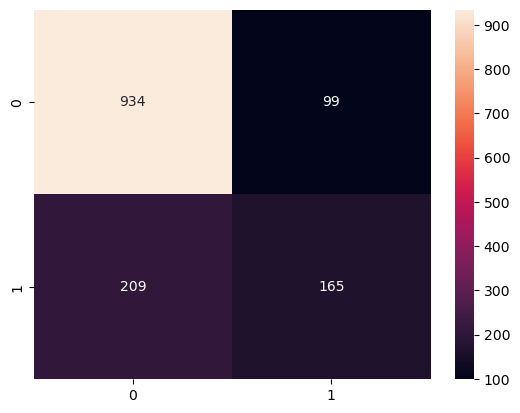

In [179]:
cm=confusion_matrix(y_test,pred3)

sns.heatmap(cm,
            annot=True,
            fmt="d")

plt.show()

In [180]:
print(classification_report(y_test,pred3))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.44      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.67      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [181]:
importance=pd.DataFrame({
    "Feature":x.columns,
    "Importance":rf.feature_importances_
})

importance=importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
18      TotalCharges    0.189902
17    MonthlyCharges    0.173810
4             tenure    0.154329
14          Contract    0.073946
8     OnlineSecurity    0.053463
16     PaymentMethod    0.052616
11       TechSupport    0.046089
7    InternetService    0.028159
9       OnlineBackup    0.027361
0             gender    0.027025
15  PaperlessBilling    0.025374
2            Partner    0.023176
6      MultipleLines    0.021971
1      SeniorCitizen    0.021593
10  DeviceProtection    0.021000
3         Dependents    0.019624
12       StreamingTV    0.017941
13   StreamingMovies    0.017423
5       PhoneService    0.005198


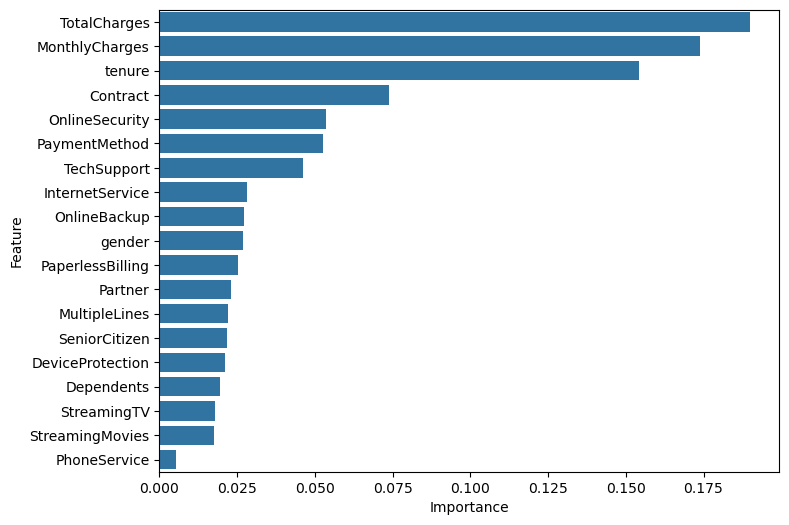

In [182]:
plt.figure(figsize=(8,6))
sns.barplot(x="Importance",y="Feature",data=importance)
plt.show()

In [183]:
sample=x.iloc[[0]]

sample=sc.transform(sample)

prediction=rf.predict(sample)

print(prediction)

[0]


In [184]:
import joblib

joblib.dump(rf,"customer_churn_model.pkl")
joblib.dump(sc,"scaler.pkl")

['scaler.pkl']